In [2]:
#!/usr/bin/env python3
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

# ---------------------------
# ustawienia stanów i akcji + mapy
# ---------------------------
STATES = [1,2,3,4,5,6,7]
ACTIONS = [0,1,2,3]
S2I = {s:i for i,s in enumerate(STATES)}
A2I = {a:i for i,a in enumerate(ACTIONS)}

# ---------------------------
# środowisko (funkcja step)
# ---------------------------
def step(state: int, action: int) -> Tuple[int, float]:
    if state == 1:
        reward = 20 * action if random.random() < 0.4 else -10 * action
        next_state = 2 if action in [2, 3] else 3
    elif state == 2:
        reward = 30 * action if random.random() < 0.4 else -25 * action
        next_state = 4 if action in [2, 3] else 5
    elif state == 3:
        reward = 30 * action if random.random() < 0.3 else -15 * action
        next_state = 6 if action in [2, 3] else 7
    elif state == 4:
        reward = 50 if random.random() < 0.8 else -15
        next_state = 1
    elif state == 5:
        reward = 15 if random.random() < 0.3 else -10
        next_state = 1
    elif state == 6:
        reward = 30 if random.random() < 0.8 else -10
        next_state = 1
    elif state == 7:
        reward = 20 if random.random() < 0.4 else -20
        next_state = 1
    else:
        raise ValueError(f"Nieznany stan: {state}")
    return int(next_state), float(reward)

In [3]:
import random
from typing import Tuple

def step_low_variance(state: int, action: int) -> Tuple[int, float]:
    """
    Alternatywne środowisko: mniejsza wariancja dla 'bezpiecznych' trajektorii.
    - akcje 2,3 traktujemy jako 'ryzykowne' (z mniejszym p sukcesu i większymi wahanami)
    - akcje 0,1 traktujemy jako 'bezpieczne' (większe p sukcesu, mniejsze porażki)
    """
    if state == 1:
        if action in [2, 3]:
            # ryzykowna gałąź (bez zmian w stosunku do oryginału)
            p = 0.4
            r_pos = 20 * action
            r_neg = -10 * action
            next_state = 2
        else:
            # mniej-risk: wyższe p sukcesu, mniejsze straty
            p = 0.8
            r_pos = 10 * action
            r_neg = -2 * action
            next_state = 3
        reward = r_pos if random.random() < p else r_neg

    elif state == 2:
        if action in [2, 3]:
            p = 0.4
            r_pos = 30 * action
            r_neg = -25 * action
            next_state = 4
        else:
            # jeśli w stanie 2 wybierzemy 'safe' akcję -> umiarkowany, pewniejszy wynik
            p = 0.6
            r_pos = 20 * action
            r_neg = -5 * action
            next_state = 5
        reward = r_pos if random.random() < p else r_neg

    elif state == 3:
        if action in [2, 3]:
            p = 0.3
            r_pos = 30 * action
            r_neg = -15 * action
            next_state = 6
        else:
            # mniej ryzykowna gałąź z niską wariancją
            p = 0.85
            r_pos = 12 * action
            r_neg = -3 * action
            next_state = 7
        reward = r_pos if random.random() < p else r_neg

    elif state == 4:
        p = 0.8
        r_pos = 50
        r_neg = -15
        reward = r_pos if random.random() < p else r_neg
        next_state = 1

    elif state == 5:
        p = 0.9
        r_pos = 15
        r_neg = -5
        reward = r_pos if random.random() < p else r_neg
        next_state = 1

    elif state == 6:
        p = 0.8
        r_pos = 30
        r_neg = -10
        reward = r_pos if random.random() < p else r_neg
        next_state = 1

    elif state == 7:
        p = 0.85
        r_pos = 12
        r_neg = -6
        reward = r_pos if random.random() < p else r_neg
        next_state = 1

    else:
        raise ValueError(f"Nieznany stan: {state}")

    return int(next_state), float(reward)


In [17]:
import numpy as np
import math

def train_q_learning_risk(
    num_episodes=1000,
    gamma=0.99,
    seed=0,
    verbose_every=100,
    # eksploracja
    eps_start=0.5,
    eps_end=0.05,
    eps_decay_frac=0.5,
    min_alpha=0.0,
    bonus_beta=0.0,
    optimistic_q=None,
    # opcja: preferowanie najmniej odwiedzanych akcji przy exploitation
    p_least_visited=0.25,
    # parametry risk-sensitive
    k1=1.0, l1=1.0, k2=1.0, l2=1.0,
    theta=0.1,
    rs_mode='entropic_RA'   # 'u', 'entropic_RA', 'entropic_RS' , 'neutral'
):
    """
    Tabularny Q-learning z możliwością testowania różnych transformacji TD:
      - 'u' : asymmetric power utility (k1,l1,k2,l2)
      - 'entropic_RA' : 1 - exp(-theta * x)
      - 'entropic_RS' : exp(theta * x)

    Uwaga: funkcja zakłada istnienie w otoczeniu zmiennych/globali:
      STATES, ACTIONS, S2I oraz funkcji step(state, action) -> (next_state, reward)

    Zwraca: q, counts, episode_rewards
    """

    rng = np.random.default_rng(seed)

    S = len(STATES)
    A = len(ACTIONS)

    # inicjalizacja Q
    if optimistic_q is None:
        q = np.zeros((S, A))
    else:
        q = np.full((S, A), optimistic_q)

    counts = np.zeros((S, A), dtype=int)
    episode_rewards = []

    def epsilon_for_episode(ep_idx):
        decay_episodes = max(1, int(eps_decay_frac * num_episodes))
        if ep_idx >= decay_episodes:
            return eps_end
        frac = ep_idx / decay_episodes
        return eps_start + frac * (eps_end - eps_start)

    # funkcja u (asymetryczna moc)
    def u(x, k1_local=k1, l1_local=l1, k2_local=k2, l2_local=l2):
        if x >= 0.0:
            return k1_local * (x ** l1_local)
        else:
            return -k2_local * ((-x) ** l2_local)

    # entropijne warianty
    def entropic_RA(x, theta_local=theta):
        return 1.0 - math.exp(- theta_local * x)

    def entropic_RS(x, theta_local=theta):
        return math.exp(theta_local * x)

    def identity(x):
        return x

    # wybierz transformację TD
    if rs_mode == 'u':
        transform = u
    elif rs_mode == 'entropic_RS':
        transform = entropic_RS
    elif rs_mode == 'entropic_RA':
        transform = entropic_RA
    else:
        transform = identity 

    for ep in range(num_episodes):
        state = rng.choice(STATES)
        total_reward = 0.0
        eps = epsilon_for_episode(ep)

        while True:
            s_i = S2I[state]

            # wybór akcji: eps-greedy + opcjonalne preferowanie najmniej odwiedzanej akcji
            if rng.random() < eps:
                a_i = int(rng.integers(0, A))
            else:
                if (p_least_visited is not None) and (rng.random() < p_least_visited):
                    minc = np.min(counts[s_i, :])
                    candidates = np.flatnonzero(counts[s_i, :] == minc)
                    a_i = int(rng.choice(candidates))
                else:
                    vals = q[s_i, :]
                    candidates = np.flatnonzero(vals == vals.max())
                    a_i = int(rng.choice(candidates))

            action = ACTIONS[a_i]

            next_state, reward = step_low_variance(state, action)    #opcjonalnie step_low_variance / step
            total_reward += reward
            ns_i = S2I[next_state]

            # aktualizacja liczników i kroku uczenia
            counts[s_i, a_i] += 1
            Nt = counts[s_i, a_i]

            alpha = 1.0 / Nt
            if min_alpha and (min_alpha > 0.0):
                alpha = max(alpha, min_alpha)

            counts_before = max(Nt - 1, 0)
            bonus = (bonus_beta / math.sqrt(counts_before + 1)) if (bonus_beta and bonus_beta > 0.0) else 0.0

            done = (next_state == 1)  # zachowano Twoją oryginalną logikę; rozważ użycie env.done jeśli dostępne
            if done:
                target = reward + bonus
            else:
                target = reward + bonus + gamma * np.max(q[ns_i, :])

            td_error = target - q[s_i, a_i]
            transformed_td = transform(td_error)
            q[s_i, a_i] = q[s_i, a_i] + alpha * transformed_td

            state = next_state
            if done:
                break

        episode_rewards.append(total_reward)

        if verbose_every and (((ep + 1) % verbose_every == 0) or ep == 0 or ep == num_episodes - 1):
            last_n = min(len(episode_rewards), verbose_every)
            avg_last = np.mean(episode_rewards[-last_n:])
            #print(f"[seed {seed}] Episode {ep+1}/{num_episodes} eps={eps:.3f} avg_reward(last {last_n}): {avg_last:.3f}")

    return q, counts, episode_rewards



=== FINAL TRAINING ===

=== TRAINING STATS ===
n_episodes: 3000
mean: 21.206333333333333
median: 15.0
std: 26.97336513221062
min: -120.0
max: 200.0

=== FINAL Q ===
[[   5.453     7.9718    2.0217   -5.1753]
 [   5.3847    7.6518  -28.022  -169.2831]
 [   5.3145    9.0665   -8.6042  -21.5589]
 [   5.8923    3.5041    5.9437    5.4502]
 [   8.0425    5.901     6.3049    6.8409]
 [   6.618     5.1777    5.5637    8.4022]
 [   4.6162    6.9419    4.7315    5.8175]]

=== FINAL COUNTS ===
[[ 44 273  44  45]
 [ 60 369  59  60]
 [ 82 510  82  81]
 [ 68  60 363  60]
 [571  91  89  91]
 [ 62  62  63 392]
 [114 688 113 113]]


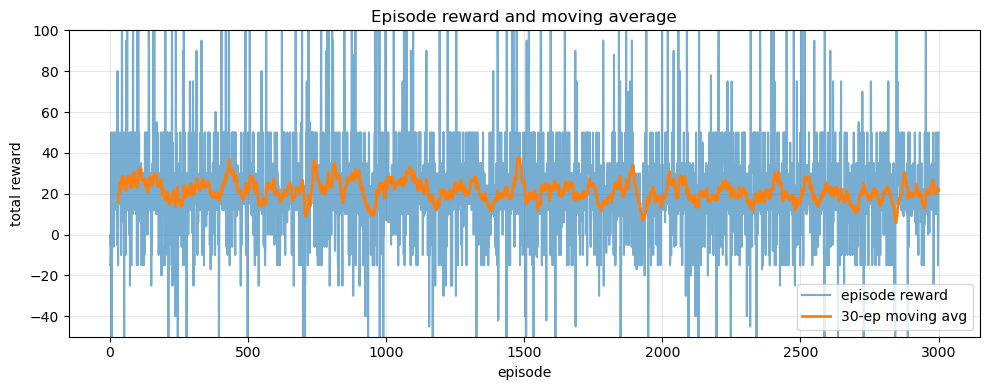

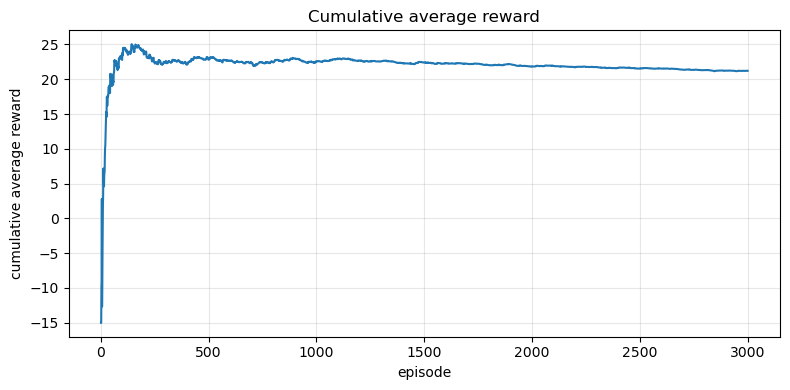

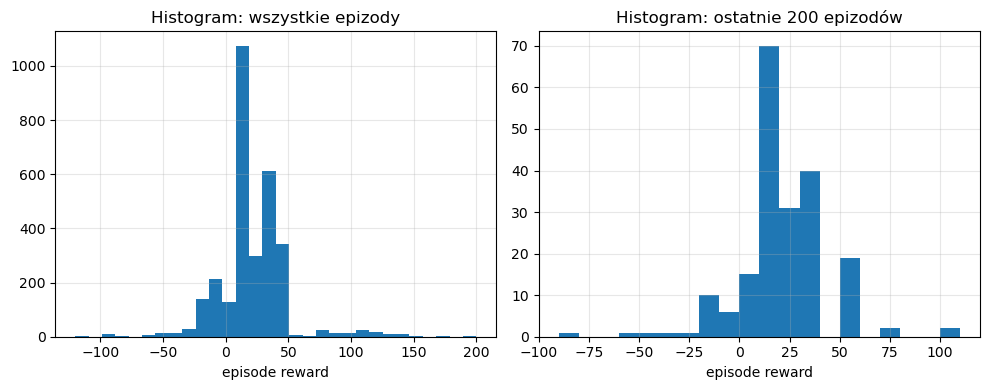


=== Q-table (numeric values) ===
        a0      a1       a2        a3
s1  5.4530  7.9718   2.0217   -5.1753
s2  5.3847  7.6518 -28.0220 -169.2831
s3  5.3145  9.0665  -8.6042  -21.5589
s4  5.8923  3.5041   5.9437    5.4502
s5  8.0425  5.9010   6.3049    6.8409
s6  6.6180  5.1777   5.5637    8.4022
s7  4.6162  6.9419   4.7315    5.8175

=== Policy (softmax probabilities, T=5) ===
        a0      a1      a2      a3
s1  0.3051  0.5049  0.1536  0.0364
s2  0.3884  0.6112  0.0005  0.0000
s3  0.3140  0.6651  0.0194  0.0015
s4  0.2820  0.1749  0.2849  0.2581
s5  0.3180  0.2072  0.2247  0.2501
s6  0.2507  0.1880  0.2031  0.3582
s7  0.2046  0.3258  0.2094  0.2602

=== SAMPLE TRAJECTORIES ANALYSIS (per unique trajectory) ===
Total episodes: 2000

Highlighted (expected) trajectories:
1->2->4->1 : not observed
1->3->7->1 : count=1569 (78.5%), mean=20.644, std=10.454

Top 10 most common trajectories (count, pct, mean, std):
trajectory  count   pct  mean_reward  std_reward
1->3->7->1   1569 78.45   

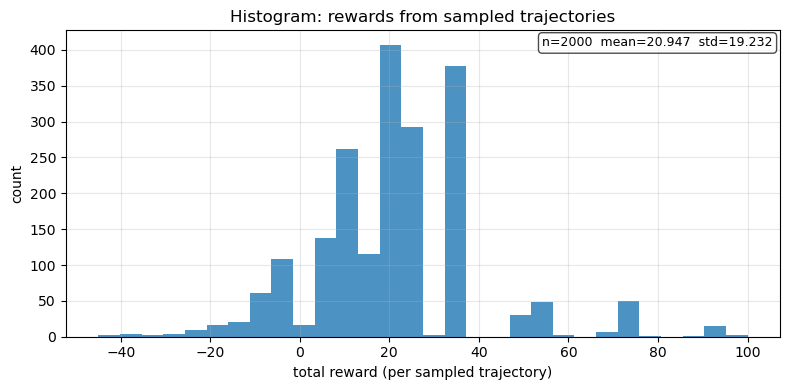

In [18]:
import numpy as np
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# ---------- PARAMETRY FINALNEGO TRENINGU ----------
final_seed = 122 + 859
final_num_episodes = 3000

eps_start = 0.5
eps_end = 0.05
eps_decay_frac = 0.5
optimistic_q = 5.0
min_alpha = 0.01
bonus_beta = 0

# risk-sensitive params
k1, l1 = 1.0, 0.5
k2, l2 = 1.0, 1.0
theta = 0.07
rs_mode = 'entropic_RA'           # wybierz 'u', 'entropic_RA', 'entropic_RS', 'neutral' 

env = step_low_variance

# polityka do symulacji i jej temperatura
policy_temperature = 5

# symulacja trajektorii
n_sample = 2000
max_steps = 50
start_state = 1
terminal_state = 1

# ---------- RUN: trening ----------
print("\n=== FINAL TRAINING ===")
q_final_risk, counts_final, ep_rewards_final = train_q_learning_risk(
    num_episodes=final_num_episodes,
    gamma=0.99,
    seed=final_seed,
    verbose_every=100,
    eps_start=eps_start,
    eps_end=eps_end,
    eps_decay_frac=eps_decay_frac,
    optimistic_q=optimistic_q,
    min_alpha=min_alpha,
    bonus_beta=bonus_beta,
    k1=k1, l1=l1, k2=k2, l2=l2, theta=theta,
    rs_mode=rs_mode
)

# ---------- PODSTAWOWE STATYSTYKI ----------
rewards = np.array(ep_rewards_final)

stats = {
    "n_episodes": len(rewards),
    "mean": float(np.mean(rewards)),
    "median": float(np.median(rewards)),
    "std": float(np.std(rewards)),
    "min": float(np.min(rewards)),
    "max": float(np.max(rewards))
}

print("\n=== TRAINING STATS ===")
for k, v in stats.items():
    print(f"{k}: {v}")

print("\n=== FINAL Q ===")
np.set_printoptions(precision=4, suppress=True)
print(q_final_risk)

print("\n=== FINAL COUNTS ===")
print(counts_final)

# ---------- WYKRESY UCZENIA ----------
# 1) surowa krzywa reward per episode + moving average
plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(ep_rewards_final)+1), ep_rewards_final, label='episode reward', alpha=0.6)
window = max(1, len(ep_rewards_final)//100)   # ~1% window
ma = np.convolve(ep_rewards_final, np.ones(window)/window, mode='valid')
plt.plot(np.arange(window, len(ep_rewards_final)+1), ma, label=f'{window}-ep moving avg', linewidth=2)
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('Episode reward and moving average')
plt.legend()
plt.grid(alpha=0.3)

# ustaw zakres osi Y
plt.ylim(-50, 100)

plt.tight_layout()
plt.show()


# 2) cumulative average reward (jak szybko stabilizuje się polityka)
cumulative_avg = np.cumsum(ep_rewards_final) / (np.arange(len(ep_rewards_final)) + 1)
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(cumulative_avg)+1), cumulative_avg)
plt.xlabel('episode')
plt.ylabel('cumulative average reward')
plt.title('Cumulative average reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) histogram rozkładu epizodowych nagród (ostatnie N i wszystkie)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(ep_rewards_final, bins=30)
plt.title('Histogram: wszystkie epizody')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
last_n = min(200, len(ep_rewards_final))
plt.hist(ep_rewards_final[-last_n:], bins=20)
plt.title(f'Histogram: ostatnie {last_n} epizodów')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Policy (softmax z Q/T) ---
def stable_softmax(arr, temp=1.0):
    z = arr / temp
    z = z - np.max(z)
    ex = np.exp(z)
    return ex / np.sum(ex)

policy_final = np.zeros_like(q_final_risk)
for s_idx in range(q_final_risk.shape[0]):
    policy_final[s_idx, :] = stable_softmax(q_final_risk[s_idx, :], temp=policy_temperature)

# --- Tabela Q-values ---
q_df = pd.DataFrame(
    q_final_risk,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print("\n=== Q-table (numeric values) ===")
print(q_df.round(4))

# --- Tabela Policy ---
policy_df = pd.DataFrame(
    policy_final,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print(f"\n=== Policy (softmax probabilities, T={policy_temperature}) ===")
print(policy_df.round(4))

# ---------- GENEROWANIE I ANALIZA TRAJEKTORII ----------
rng = np.random.default_rng(final_seed + 134)

# Zaktualizowana funkcja: zwraca zarówno listę stanów, jak i sumaryczną nagrodę epizodu
def run_episode_with_policy(q_table, temperature, rng, start_state=1, terminal_state=1, max_steps=50):
    states = [start_state]
    state = start_state
    total_reward = 0.0
    for _ in range(max_steps):
        s_idx = S2I[state]
        probs = stable_softmax(q_table[s_idx, :], temperature)
        a_idx = int(rng.choice(len(probs), p=probs))
        action = ACTIONS[a_idx]
        next_state, reward = env(state, action)
        total_reward += reward
        states.append(next_state)
        state = next_state
        if state == terminal_state:
            break
    return states, total_reward

# --- Sampling: gromadzenie listy trajektorii i nagród dla każdej unikalnej trajektorii ---
traj_rewards = {}   # map: traj_tuple -> list of total rewards
traj_counts = Counter()
all_trajectories = []

for _ in range(n_sample):
    traj, ep_reward = run_episode_with_policy(q_final_risk, policy_temperature, rng,
                                              start_state=start_state,
                                              terminal_state=terminal_state,
                                              max_steps=max_steps)
    traj_t = tuple(traj)
    all_trajectories.append(traj)
    traj_counts[traj_t] += 1
    traj_rewards.setdefault(traj_t, []).append(ep_reward)

# --- Oblicz statystyki (count, pct, mean, std) dla każdej trajektorii ---
rows = []
for traj_t, rewards in traj_rewards.items():
    count = len(rewards)
    pct = 100.0 * count / n_sample
    mean = float(np.mean(rewards))
    std = float(np.std(rewards))
    rows.append({
        "trajectory": "->".join(map(str, traj_t)),
        "count": count,
        "pct": pct,
        "mean_reward": mean,
        "std_reward": std
    })

df_traj_stats = pd.DataFrame(rows)
df_traj_stats = df_traj_stats.sort_values(by="count", ascending=False).reset_index(drop=True)

# --- Wydrukuj wyróżnione trajektorie 1->2->4->1 oraz 1->3->7->1, jeśli wystąpiły ---
def print_traj_stats(df, traj_list):
    for t in traj_list:
        tstr = "->".join(map(str, t))
        row = df[df["trajectory"] == tstr]
        if not row.empty:
            r = row.iloc[0]
            print(f"{tstr} : count={int(r['count'])} ({r['pct']:.1f}%), mean={r['mean_reward']:.3f}, std={r['std_reward']:.3f}")
        else:
            print(f"{tstr} : not observed")

print("\n=== SAMPLE TRAJECTORIES ANALYSIS (per unique trajectory) ===")
print(f"Total episodes: {n_sample}\n")
print("Highlighted (expected) trajectories:")
print_traj_stats(df_traj_stats, [[1,2,4,1], [1,3,7,1]])

# --- Top-10 najczęstszych trajektorii z ich statystykami ---
top_n = 10
print(f"\nTop {top_n} most common trajectories (count, pct, mean, std):")
print(df_traj_stats.head(top_n).to_string(index=False))

# --- Podsumowanie 'mixed' (czyli wszystkie trajektorie poza dwoma wyróżnionymi) ---
highlight_set = {"1->2->4->1", "1->3->7->1"}
mixed_df = df_traj_stats[~df_traj_stats["trajectory"].isin(highlight_set)]
mixed_total_count = mixed_df["count"].sum()
mixed_total_pct = 100.0 * mixed_total_count / n_sample
mixed_mean, mixed_std = (float(np.nan), float(np.nan))
if mixed_total_count > 0:
    # obliczamy łączną średnią i std po rozbiciu na wszystkie trajektorie (ważone wystąpieniami)
    # mean_all = sum(mean_i * count_i) / total_count
    weighted_sum = (mixed_df["mean_reward"] * mixed_df["count"]).sum()
    mixed_mean = weighted_sum / mixed_total_count
    # dla std: obliczamy wariancję całkowitą = (sum(var_i * (n_i -1) + n_i * mean_i^2) - N * mean_all^2) / (N)
    sum_sq = ((mixed_df["std_reward"]**2) * (mixed_df["count"] - 1)).sum() + (mixed_df["mean_reward"]**2 * mixed_df["count"]).sum()
    mixed_var = (sum_sq / mixed_total_count) - (mixed_mean**2)
    mixed_std = float(np.sqrt(max(0.0, mixed_var)))

print(f"\n'Mixed' trajectories (all other than highlighted): count={int(mixed_total_count)} ({mixed_total_pct:.1f}%), mean={mixed_mean:.3f}, std={mixed_std:.3f}")

# spłaszczamy listy nagród dla wszystkich zsample'owanych trajektorii
sampled_rewards = [r for rewards in traj_rewards.values() for r in rewards]

plt.figure(figsize=(8,4))
plt.hist(sampled_rewards, bins=30, alpha=0.8)
plt.xlabel("total reward (per sampled trajectory)")
plt.ylabel("count")
plt.title("Histogram: rewards from sampled trajectories")
# wypisz podstawowe statystyki w legendzie / tytule
mean_sr = np.mean(sampled_rewards) if len(sampled_rewards) > 0 else float("nan")
std_sr  = np.std(sampled_rewards)  if len(sampled_rewards) > 0 else float("nan")
plt.annotate(f"n={len(sampled_rewards)}  mean={mean_sr:.3f}  std={std_sr:.3f}",
             xy=(0.99, 0.98), xycoords="axes fraction",
             va="top", ha="right", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


=== FINAL TRAINING ===

=== TRAINING STATS ===
n_episodes: 3000
mean: 22.088666666666665
median: 15.0
std: 41.56357545843343
min: -120.0
max: 200.0

=== FINAL Q ===
[[20.3843 28.3853 41.8198 38.5303]
 [13.1545 21.1591 28.9081 41.8442]
 [ 9.6399 18.4916 18.2658 13.7519]
 [36.0211 36.7194 37.1464 34.9764]
 [13.7992 12.2594 12.8164 12.553 ]
 [19.7959 18.5714 20.0545 23.7709]
 [ 8.4     9.3875  8.6336  9.    ]]

=== FINAL COUNTS ===
[[ 62  61 158 131]
 [ 97  97 131 384]
 [ 74 152 248  74]
 [208 364 194 188]
 [267 109 110 160]
 [ 98  98 258 297]
 [ 95 332 126  96]]


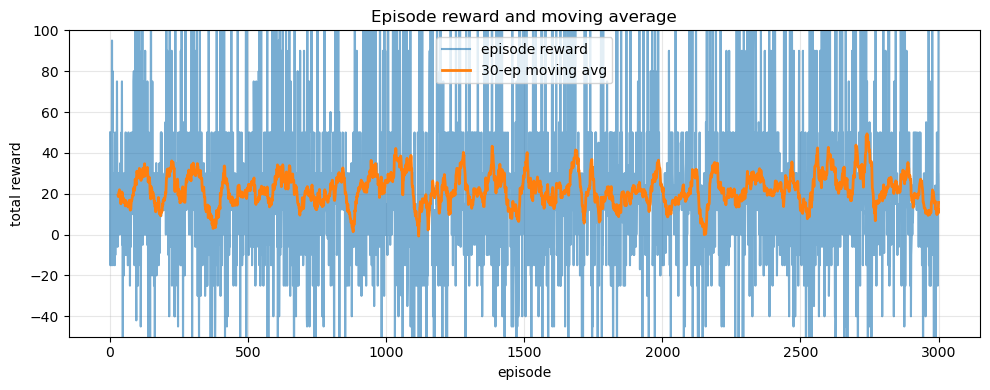

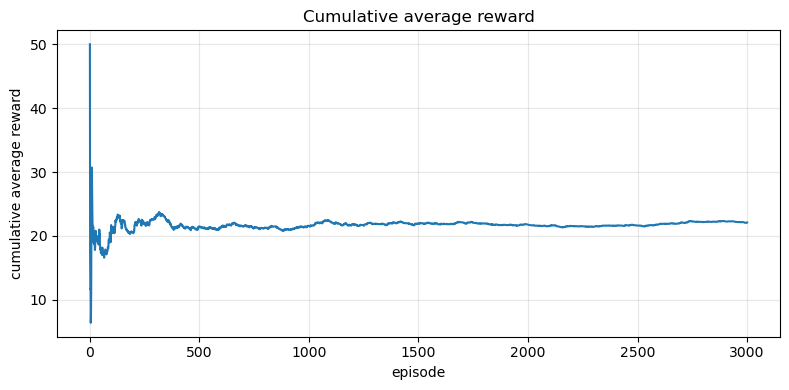

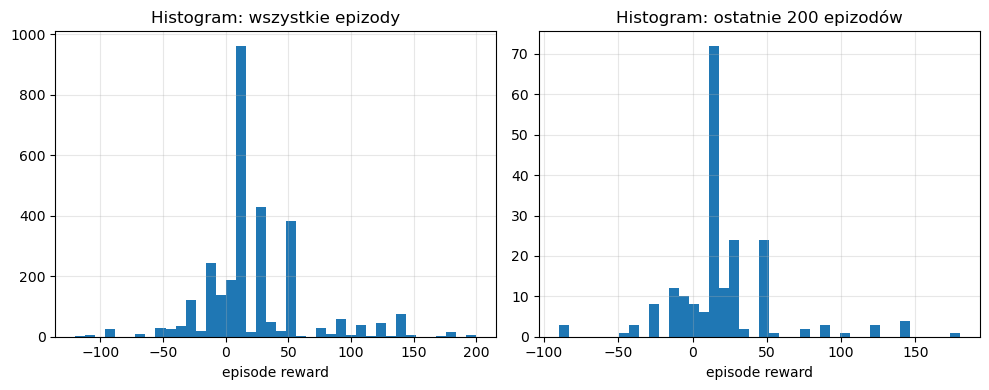


=== Q-table (numeric values) ===
         a0       a1       a2       a3
s1  20.3843  28.3853  41.8198  38.5303
s2  13.1545  21.1591  28.9081  41.8442
s3   9.6399  18.4916  18.2658  13.7519
s4  36.0211  36.7194  37.1464  34.9764
s5  13.7992  12.2594  12.8164  12.5530
s6  19.7959  18.5714  20.0545  23.7709
s7   8.4000   9.3875   8.6336   9.0000

=== Policy (softmax probabilities, T=5) ===
        a0      a1      a2      a3
s1  0.0086  0.0426  0.6251  0.3238
s2  0.0029  0.0146  0.0687  0.9137
s3  0.0677  0.3978  0.3803  0.1542
s4  0.2373  0.2729  0.2972  0.1926
s5  0.2998  0.2203  0.2463  0.2336
s6  0.1980  0.1550  0.2085  0.4385
s7  0.2276  0.2773  0.2385  0.2566

=== SAMPLE TRAJECTORIES ANALYSIS (per unique trajectory) ===
Total episodes: 2000

Highlighted (expected) trajectories:
1->2->4->1 : count=1853 (92.7%), mean=33.826, std=90.393
1->3->7->1 : count=51 (2.5%), mean=21.118, std=10.238

Top 10 most common trajectories (count, pct, mean, std):
trajectory  count   pct  mean_reward  s

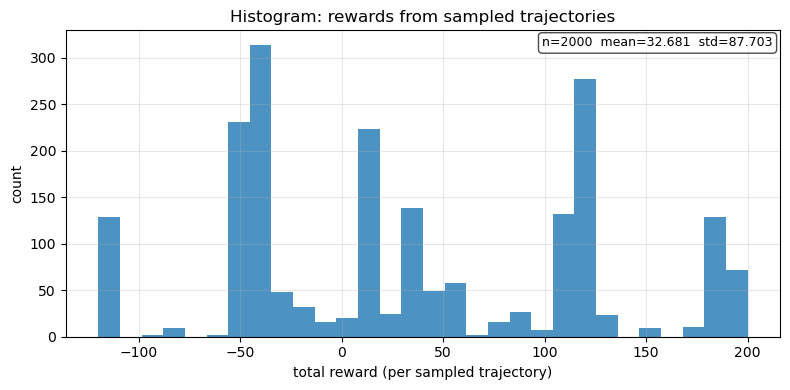

In [19]:
import numpy as np
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# ---------- PARAMETRY FINALNEGO TRENINGU ----------
final_seed = 122 + 859
final_num_episodes = 3000

eps_start = 0.5
eps_end = 0.05
eps_decay_frac = 0.5
optimistic_q = 5.0
min_alpha = 0.01
bonus_beta = 0

# risk-sensitive params
k1, l1 = 1.0, 0.5
k2, l2 = 1.0, 1.0
theta = 0.07
rs_mode = 'neutral'           # wybierz 'u', 'entropic_RA', 'entropic_RS', 'neutral' 

env = step_low_variance

# polityka do symulacji i jej temperatura
policy_temperature = 5

# symulacja trajektorii
n_sample = 2000
max_steps = 50
start_state = 1
terminal_state = 1

# ---------- RUN: trening ----------
print("\n=== FINAL TRAINING ===")
q_final_risk, counts_final, ep_rewards_final = train_q_learning_risk(
    num_episodes=final_num_episodes,
    gamma=0.99,
    seed=final_seed,
    verbose_every=100,
    eps_start=eps_start,
    eps_end=eps_end,
    eps_decay_frac=eps_decay_frac,
    optimistic_q=optimistic_q,
    min_alpha=min_alpha,
    bonus_beta=bonus_beta,
    k1=k1, l1=l1, k2=k2, l2=l2, theta=theta,
    rs_mode=rs_mode
)

# ---------- PODSTAWOWE STATYSTYKI ----------
rewards = np.array(ep_rewards_final)

stats = {
    "n_episodes": len(rewards),
    "mean": float(np.mean(rewards)),
    "median": float(np.median(rewards)),
    "std": float(np.std(rewards)),
    "min": float(np.min(rewards)),
    "max": float(np.max(rewards))
}

print("\n=== TRAINING STATS ===")
for k, v in stats.items():
    print(f"{k}: {v}")

print("\n=== FINAL Q ===")
np.set_printoptions(precision=4, suppress=True)
print(q_final_risk)

print("\n=== FINAL COUNTS ===")
print(counts_final)

# ---------- WYKRESY UCZENIA ----------
# 1) surowa krzywa reward per episode + moving average
plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(ep_rewards_final)+1), ep_rewards_final, label='episode reward', alpha=0.6)
window = max(1, len(ep_rewards_final)//100)   # ~1% window
ma = np.convolve(ep_rewards_final, np.ones(window)/window, mode='valid')
plt.plot(np.arange(window, len(ep_rewards_final)+1), ma, label=f'{window}-ep moving avg', linewidth=2)
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('Episode reward and moving average')
plt.legend()
plt.grid(alpha=0.3)

# ustaw zakres osi Y
plt.ylim(-50, 100)

plt.tight_layout()
plt.show()


# 2) cumulative average reward (jak szybko stabilizuje się polityka)
cumulative_avg = np.cumsum(ep_rewards_final) / (np.arange(len(ep_rewards_final)) + 1)
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(cumulative_avg)+1), cumulative_avg)
plt.xlabel('episode')
plt.ylabel('cumulative average reward')
plt.title('Cumulative average reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) histogram rozkładu epizodowych nagród (ostatnie N i wszystkie)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(ep_rewards_final, bins=40)
plt.title('Histogram: wszystkie epizody')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
last_n = min(200, len(ep_rewards_final))
plt.hist(ep_rewards_final[-last_n:], bins=40)
plt.title(f'Histogram: ostatnie {last_n} epizodów')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Policy (softmax z Q/T) ---
def stable_softmax(arr, temp=1.0):
    z = arr / temp
    z = z - np.max(z)
    ex = np.exp(z)
    return ex / np.sum(ex)

policy_final = np.zeros_like(q_final_risk)
for s_idx in range(q_final_risk.shape[0]):
    policy_final[s_idx, :] = stable_softmax(q_final_risk[s_idx, :], temp=policy_temperature)

# --- Tabela Q-values ---
q_df = pd.DataFrame(
    q_final_risk,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print("\n=== Q-table (numeric values) ===")
print(q_df.round(4))

# --- Tabela Policy ---
policy_df = pd.DataFrame(
    policy_final,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print(f"\n=== Policy (softmax probabilities, T={policy_temperature}) ===")
print(policy_df.round(4))

# ---------- GENEROWANIE I ANALIZA TRAJEKTORII ----------
rng = np.random.default_rng(final_seed + 134)

# Zaktualizowana funkcja: zwraca zarówno listę stanów, jak i sumaryczną nagrodę epizodu
def run_episode_with_policy(q_table, temperature, rng, start_state=1, terminal_state=1, max_steps=50):
    states = [start_state]
    state = start_state
    total_reward = 0.0
    for _ in range(max_steps):
        s_idx = S2I[state]
        probs = stable_softmax(q_table[s_idx, :], temperature)
        a_idx = int(rng.choice(len(probs), p=probs))
        action = ACTIONS[a_idx]
        next_state, reward = env(state, action)
        total_reward += reward
        states.append(next_state)
        state = next_state
        if state == terminal_state:
            break
    return states, total_reward

# --- Sampling: gromadzenie listy trajektorii i nagród dla każdej unikalnej trajektorii ---
traj_rewards = {}   # map: traj_tuple -> list of total rewards
traj_counts = Counter()
all_trajectories = []

for _ in range(n_sample):
    traj, ep_reward = run_episode_with_policy(q_final_risk, policy_temperature, rng,
                                              start_state=start_state,
                                              terminal_state=terminal_state,
                                              max_steps=max_steps)
    traj_t = tuple(traj)
    all_trajectories.append(traj)
    traj_counts[traj_t] += 1
    traj_rewards.setdefault(traj_t, []).append(ep_reward)

# --- Oblicz statystyki (count, pct, mean, std) dla każdej trajektorii ---
rows = []
for traj_t, rewards in traj_rewards.items():
    count = len(rewards)
    pct = 100.0 * count / n_sample
    mean = float(np.mean(rewards))
    std = float(np.std(rewards))
    rows.append({
        "trajectory": "->".join(map(str, traj_t)),
        "count": count,
        "pct": pct,
        "mean_reward": mean,
        "std_reward": std
    })

df_traj_stats = pd.DataFrame(rows)
df_traj_stats = df_traj_stats.sort_values(by="count", ascending=False).reset_index(drop=True)

# --- Wydrukuj wyróżnione trajektorie 1->2->4->1 oraz 1->3->7->1, jeśli wystąpiły ---
def print_traj_stats(df, traj_list):
    for t in traj_list:
        tstr = "->".join(map(str, t))
        row = df[df["trajectory"] == tstr]
        if not row.empty:
            r = row.iloc[0]
            print(f"{tstr} : count={int(r['count'])} ({r['pct']:.1f}%), mean={r['mean_reward']:.3f}, std={r['std_reward']:.3f}")
        else:
            print(f"{tstr} : not observed")

print("\n=== SAMPLE TRAJECTORIES ANALYSIS (per unique trajectory) ===")
print(f"Total episodes: {n_sample}\n")
print("Highlighted (expected) trajectories:")
print_traj_stats(df_traj_stats, [[1,2,4,1], [1,3,7,1]])

# --- Top-10 najczęstszych trajektorii z ich statystykami ---
top_n = 10
print(f"\nTop {top_n} most common trajectories (count, pct, mean, std):")
print(df_traj_stats.head(top_n).to_string(index=False))

# --- Podsumowanie 'mixed' (czyli wszystkie trajektorie poza dwoma wyróżnionymi) ---
highlight_set = {"1->2->4->1", "1->3->7->1"}
mixed_df = df_traj_stats[~df_traj_stats["trajectory"].isin(highlight_set)]
mixed_total_count = mixed_df["count"].sum()
mixed_total_pct = 100.0 * mixed_total_count / n_sample
mixed_mean, mixed_std = (float(np.nan), float(np.nan))
if mixed_total_count > 0:
    # obliczamy łączną średnią i std po rozbiciu na wszystkie trajektorie (ważone wystąpieniami)
    # mean_all = sum(mean_i * count_i) / total_count
    weighted_sum = (mixed_df["mean_reward"] * mixed_df["count"]).sum()
    mixed_mean = weighted_sum / mixed_total_count
    # dla std: obliczamy wariancję całkowitą = (sum(var_i * (n_i -1) + n_i * mean_i^2) - N * mean_all^2) / (N)
    sum_sq = ((mixed_df["std_reward"]**2) * (mixed_df["count"] - 1)).sum() + (mixed_df["mean_reward"]**2 * mixed_df["count"]).sum()
    mixed_var = (sum_sq / mixed_total_count) - (mixed_mean**2)
    mixed_std = float(np.sqrt(max(0.0, mixed_var)))

print(f"\n'Mixed' trajectories (all other than highlighted): count={int(mixed_total_count)} ({mixed_total_pct:.1f}%), mean={mixed_mean:.3f}, std={mixed_std:.3f}")

# spłaszczamy listy nagród dla wszystkich zsample'owanych trajektorii
sampled_rewards = [r for rewards in traj_rewards.values() for r in rewards]

plt.figure(figsize=(8,4))
plt.hist(sampled_rewards, bins=30, alpha=0.8)
plt.xlabel("total reward (per sampled trajectory)")
plt.ylabel("count")
plt.title("Histogram: rewards from sampled trajectories")
# wypisz podstawowe statystyki w legendzie / tytule
mean_sr = np.mean(sampled_rewards) if len(sampled_rewards) > 0 else float("nan")
std_sr  = np.std(sampled_rewards)  if len(sampled_rewards) > 0 else float("nan")
plt.annotate(f"n={len(sampled_rewards)}  mean={mean_sr:.3f}  std={std_sr:.3f}",
             xy=(0.99, 0.98), xycoords="axes fraction",
             va="top", ha="right", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()